In [63]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from src import util_analysis 
from scipy import stats 


In [75]:
### Import pre-formated data 

results_dir = Path('final_results_dir')

# diotic SWC 
diotic_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_SWC_diotic_conditions_humans_N-195_models_v10_w_control_archs.pdpkl")
# diotic_results

# Popham SWC
popham_results = pd.read_pickle(results_dir / "df_for_stats_2024_SWC_popham_conditions_humans_N-90_models_v10_w_control_archs.pdpkl")
popham_results['snr'] = 0 # add snr column to match diotic_results
popham_conds_to_keep = ['Harmonic_target_Harmonic_distractor',
                        'Harmonic_target_No Distractor_distractor',
                        'Inharmonic_target_Inharmonic_distractor',
                        'Inharmonic_target_No Distractor_distractor',
                        'Whispered_target_No Distractor_distractor',
                        'Whispered_target_Whispered_distractor']

popham_results = popham_results[popham_results['background_condition'].isin(popham_conds_to_keep)].reset_index(drop=True)

In [88]:
combined_results = pd.concat([diotic_results, popham_results], axis=0)

In [89]:
combined_results

,model,snr,background_condition,accuracy,acc_sem,confusions,conf_sem,group,N
0,Feature-gain Model,-9,1-talker,0.236168,0.009616,0.294057,0.010315,Feature-gain Model,NaN
1,Feature-gain Model,-9,2-talker,0.066598,0.007985,0.289959,0.014531,Feature-gain Model,NaN
2,Feature-gain Model,-9,4-talker,0.044057,0.006572,0.069672,0.008154,Feature-gain Model,NaN
3,Feature-gain Model,-9,Different sex,0.414617,0.009106,0.048839,0.003984,Feature-gain Model,NaN
4,Feature-gain Model,-9,Mandarin distractor,0.378586,0.010981,0.003074,0.001253,Feature-gain Model,NaN
...,...,...,...,...,...,...,...,...,...
79,Baseline CNN,0,Harmonic_target_No Distractor_distractor,0.777152,0.009380,0.002561,0.001143,Baseline CNN,1.0
80,Baseline CNN,0,Inharmonic_target_Inharmonic_distractor,0.328893,0.011120,0.115266,0.007271,Baseline CNN,1.0
81,Baseline CNN,0,Inharmonic_target_No Distractor_distractor,0.776639,0.009334,0.002561,0.001196,Baseline CNN,1.0
82,Baseline CNN,0,Whispered_target_No Distractor_distractor,0.741291,0.010149,0.002049,0.001036,Baseline CNN,1.0


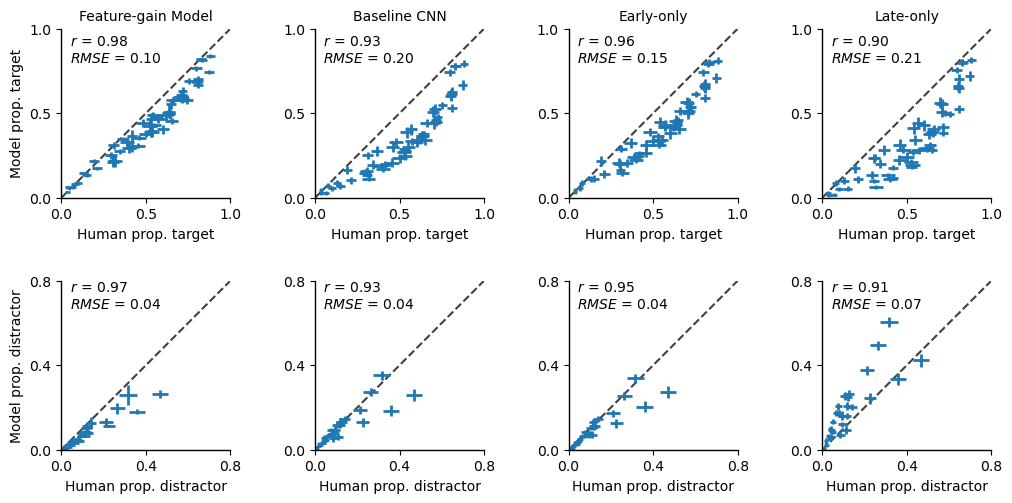

In [227]:
# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',
#              'Same sex', 'Different sex', 'Mandarin distractor', 
#              'noise', 'music', 'natural scene',
#              'Harmonic_target_Harmonic_distractor',
#             'Harmonic_target_No Distractor_distractor',
#             'Inharmonic_target_Inharmonic_distractor',
#             'Inharmonic_target_No Distractor_distractor',
#             'Whispered_target_No Distractor_distractor',
#             'Whispered_target_Whispered_distractor'
#              ]

# palette={}
# palette['clean'] = 'k'
# palette['1-talker'] = 'tab:pink'
# palette['2-talker'] = 'y'
# palette['babble'] = 'tab:orange'
# palette['4-talker'] = 'tab:red'
# palette['noise'] = 'grey'
# palette['music'] = 'tab:purple'
# palette['natural scene'] = 'tab:brown'
# # add same vs different sex 
# sex_order = ['Different sex', 'Same sex']
# sex_palette = dict(zip(sex_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
# palette['Same sex'] = sex_palette['Same sex']
# palette['Different sex'] = 'tab:cyan'
# palette['Mandarin distractor'] =  'seagreen'
# palette['Mandarin distractor'] =  'seagreen'

combined_results['snr_condition_str'] = combined_results['snr'].astype(str) + ' dB ' + combined_results['background_condition']
human_results = combined_results[combined_results.group.str.contains('Human')]
human_results = human_results.sort_values(['snr', 'background_condition'])

model_list = [model for model in combined_results.group.unique() if 'Human' not in model]

model_acc_r = []
model_conf_r = []
model_acc_rmse = []
model_conf_rmse = []

x = y = np.linspace(0,1,5)
fontsize = 10
aspect = 3

sem_order = 2 # 2 for 95% CI, 1 for SEM

fig, axs = plt.subplots(2, len(model_list), 
                        figsize=((aspect * len(model_list)),
                        aspect*2))
acc_axs = axs[0,:]
conf_axs = axs[1,:]

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for i in range(2):
    for j in range(1 + len(model_list)):
        if j != len(model_list):
            axs[i,j].plot(x,y, ls='dashed', color='k', alpha=0.75)


vert_spacing = 0.1 
conf_max_y = 0.8

model_r2_dict = {}
model_rmse_dict = {}
for ix, model in enumerate(model_list):
    if model == 'Feature-gain Model':
        fba_to_plot = combined_results[combined_results.group.str.contains('Feature')].groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
        fba_to_plot.columns = ['snr', 'background_condition', 'accuracy', 'acc_sem', 'confusions', 'conf_sem']
        fba_to_plot['snr_condition_str'] = fba_to_plot['snr'].astype(str) + ' dB ' + fba_to_plot['background_condition']

        fba_to_plot['group'] = 'Feature-gain model'
        model_results = fba_to_plot.sort_values(['snr', 'background_condition'])
    else:
        model_results = combined_results[combined_results.group == model]
        model_results = model_results.sort_values(['snr', 'background_condition'])

    # get missing snr x background conditions 
    model_conds = model_results.snr_condition_str.unique()
    human_conds = human_results.snr_condition_str.unique()
    conds_to_keep = human_conds[np.isin(human_conds, model_conds)]

    human_to_plot = human_results[human_results.snr_condition_str.isin(conds_to_keep)].copy()
    model_to_plot = model_results[model_results.snr_condition_str.isin(conds_to_keep)].copy()
    

    acc_axs[ix].errorbar(x=human_to_plot.accuracy, y=model_to_plot.accuracy,
                          xerr=human_to_plot.acc_sem * sem_order,
                         yerr=model_to_plot.acc_sem * sem_order, 
                         marker='',
                linestyle='', ms=3, elinewidth=line_width,)
    
    conf_axs[ix].errorbar(x=human_to_plot.confusions, y=model_to_plot.confusions,
                          xerr=human_to_plot.conf_sem * sem_order,
                          yerr=model_to_plot.conf_sem * sem_order,
                            marker='',
                linestyle='', ms=3, elinewidth=line_width,)
    
    acc_axs[ix].set_title(model, fontsize=fontsize)
    acc_axs[ix].set_xlabel(f"Human prop. target", fontsize=fontsize)
    conf_axs[ix].set_xlabel(f"Human prop. distractor", fontsize=fontsize)

    ## Add stats 
    r, p = stats.pearsonr(human_to_plot.accuracy,  model_to_plot.accuracy)
    # spearman_brown_r = r / np.sqrt(main_model_rho_acc)
    acc_axs[ix].annotate(f"$r$ = {r:.2f}", (0.05, 0.9), fontsize=fontsize)

    # add to dict 
    model_r2_dict[model] = {}
    model_rmse_dict[model] = {}

    samp_rmse = np.sqrt(np.mean((human_to_plot.accuracy.values - model_to_plot.accuracy.values)**2))
    acc_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.05, 0.8), fontsize=fontsize)
    model_r2_dict[model]['accuracy'] = r**2
    model_rmse_dict[model]['accuracy'] = samp_rmse

    # conf errors
    r, p = stats.pearsonr(human_to_plot.confusions, model_to_plot.confusions)
    conf_axs[ix].annotate(f"$r$ = {r:.2f}", (0.04, 0.75), fontsize=fontsize) 
    samp_rmse = np.sqrt(np.mean((human_to_plot.confusions.values - model_to_plot.confusions.values)**2))

    conf_rmse_y = 0.75 - (vert_spacing * conf_max_y)
    conf_axs[ix].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.04, conf_rmse_y), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    model_r2_dict[model]['confusions'] = r
    model_rmse_dict[model]['confusions'] = samp_rmse
    

    # set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in acc_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

ticks = np.linspace(0,.8,3).round(1)

for ax in conf_axs.flat:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')

acc_axs[0].set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs[0].set_ylabel(f"Model prop. distractor", fontsize=fontsize)

sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ax in axs.flat:
    ax.set(aspect='equal')

Text(0, 0.5, 'Human-model similarity ($RMSE$)')

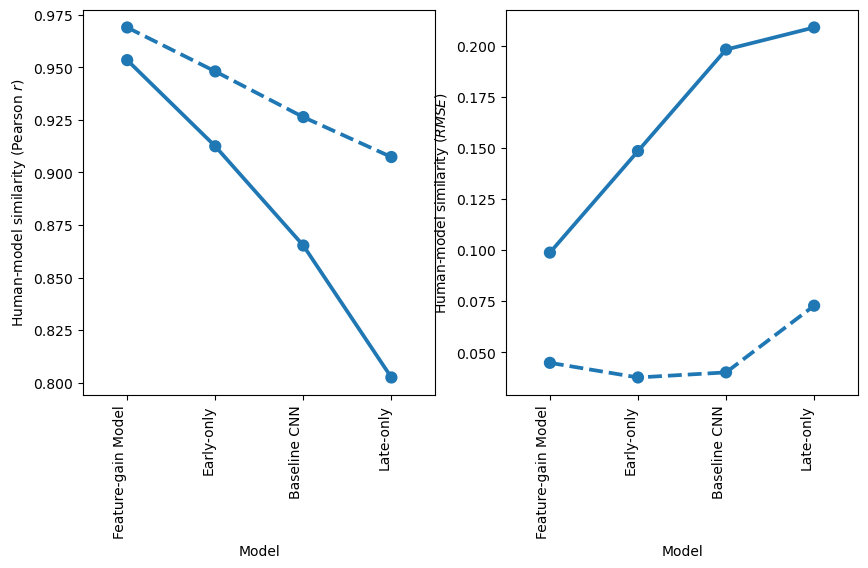

In [231]:
## Make double bar chart of r and RMSE
r_df = pd.DataFrame(model_r2_dict).T
rmse_df = pd.DataFrame(model_rmse_dict).T

fig, axs = plt.subplots(1,2, figsize=(10,5))

# x order is index sorted by r_df.accuracy 
order = r_df.accuracy.sort_values(ascending=False).index
r_df = r_df.loc[order]
# x_order = r_df.index

rmse_order = rmse_df.accuracy.sort_values(ascending=True).index
rmse_df = rmse_df.loc[rmse_order]



sns.pointplot(data=r_df, x=r_df.index, y=r_df.accuracy, ax=axs[0], linestyles='-', label='Accuracy')
sns.pointplot(data=r_df, x=r_df.index, y=r_df.confusions, ax=axs[0], linestyles='--', label='Confusions')

sns.pointplot(data=rmse_df, x=rmse_df.index, y=rmse_df.accuracy, ax=axs[1], linestyles='-', label='Accuracy')
sns.pointplot(data=rmse_df, x=rmse_df.index, y=rmse_df.confusions, ax=axs[1], linestyles='--', label='Confusions')

for ax in axs:
    # ax.set_ylim(0,1)
    ax.set_xlabel('Model')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')

axs[0].set_ylabel("Human-model similarity (Pearson $r$)")
axs[1].set_ylabel('Human-model similarity ($RMSE$)')
# axs[0].set_title('Task-Accuracy')
# axs[0].set_title('Task-Confusions')



In [ ]:
#